# TransformerLens vs HuggingFace Performance Visualization

This notebook visualizes the benchmark results comparing TransformerLens and HuggingFace implementations.

In [46]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Figure settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load Benchmark Results

In [47]:
# Find the latest result file
results_dir = Path('../../results/tl_vs_hf')

if results_dir.exists():
    json_files = list(results_dir.glob('comparison_*.json'))
    if json_files:
        # Use the most recent file
        latest_file = max(json_files, key=lambda x: x.stat().st_mtime)
        print(f"Loading results from: {latest_file}")
        
        with open(latest_file, 'r') as f:
            data = json.load(f)
            
        metadata = data['metadata']
        results = data['results']
        
        print(f"Model: {metadata['model']}")
        print(f"Device: {metadata['device']}")
        print(f"GPU: {metadata['gpu_name']}")
        print(f"Number of results: {len(results)}")
    else:
        print("No result files found. Please run the benchmark first.")
        print("Run: python benchmark/tests/tl_vs_hf_comparison.py")
else:
    print(f"Results directory {results_dir} does not exist.")
    print("Please run the benchmark first.")

Loading results from: ../../results/tl_vs_hf/comparison_gpt2_20250828_225252.json
Model: gpt2
Device: cuda
GPU: NVIDIA GeForce RTX 4090
Number of results: 36


In [48]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(results)

# Display basic statistics
print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nImplementations:", df['implementation'].unique())
print("\nBatch sizes:", sorted(df['batch_size'].unique()))
print("\nSequence lengths:", sorted(df['sequence_length'].unique()))

df.head()

Data shape: (36, 9)

Columns: ['implementation', 'load_time_sec', 'throughput_tokens_per_sec', 'latency_ms_per_batch', 'memory_mb', 'peak_memory_mb', 'total_time_sec', 'batch_size', 'sequence_length']

Implementations: ['HuggingFace' 'TransformerLens (no cache)' 'TransformerLens (with cache)']

Batch sizes: [1, 4, 8, 16]

Sequence lengths: [128, 256, 512]


,implementation,load_time_sec,throughput_tokens_per_sec,latency_ms_per_batch,memory_mb,peak_memory_mb,total_time_sec,batch_size,sequence_length
0,HuggingFace,0.245783,25273.965226,5.064500,0.000000,572.048828,0.050645,1,128
1,TransformerLens (no cache),0.858996,11875.354408,10.778626,0.000000,692.568848,0.107786,1,128
2,TransformerLens (with cache),0.806415,7425.979028,17.236784,-81.623047,798.356445,0.172368,1,128
3,HuggingFace,0.221471,88368.451587,5.793923,114.118652,801.914062,0.057939,4,128
4,TransformerLens (no cache),1.109971,44278.046883,11.563292,73.618652,841.434082,0.115633,4,128


## 2. Memory Usage Analysis

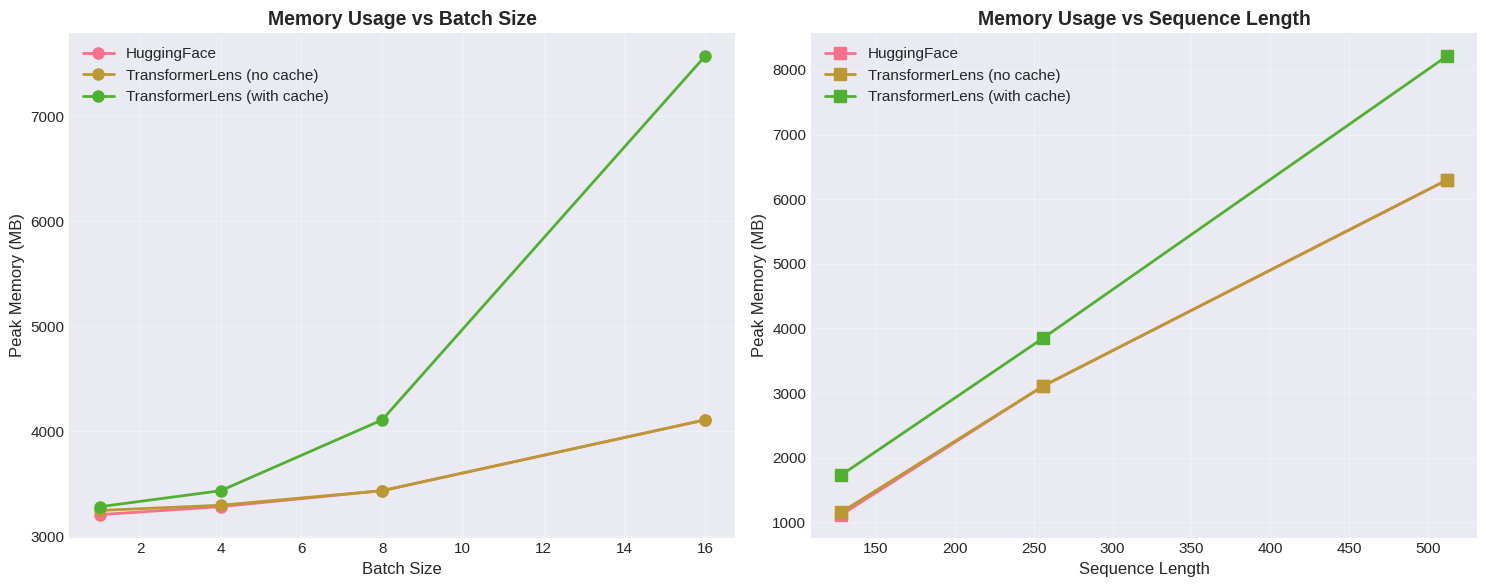

In [49]:
# Memory usage by batch size and sequence length
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Memory by batch size
ax1 = axes[0]
for impl in df['implementation'].unique():
    impl_df = df[df['implementation'] == impl]
    grouped = impl_df.groupby('batch_size')['peak_memory_mb'].mean()
    ax1.plot(grouped.index, grouped.values, marker='o', label=impl, linewidth=2, markersize=8)

ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Peak Memory (MB)', fontsize=12)
ax1.set_title('Memory Usage vs Batch Size', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Memory by sequence length
ax2 = axes[1]
for impl in df['implementation'].unique():
    impl_df = df[df['implementation'] == impl]
    grouped = impl_df.groupby('sequence_length')['peak_memory_mb'].mean()
    ax2.plot(grouped.index, grouped.values, marker='s', label=impl, linewidth=2, markersize=8)

ax2.set_xlabel('Sequence Length', fontsize=12)
ax2.set_ylabel('Peak Memory (MB)', fontsize=12)
ax2.set_title('Memory Usage vs Sequence Length', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Latency Analysis

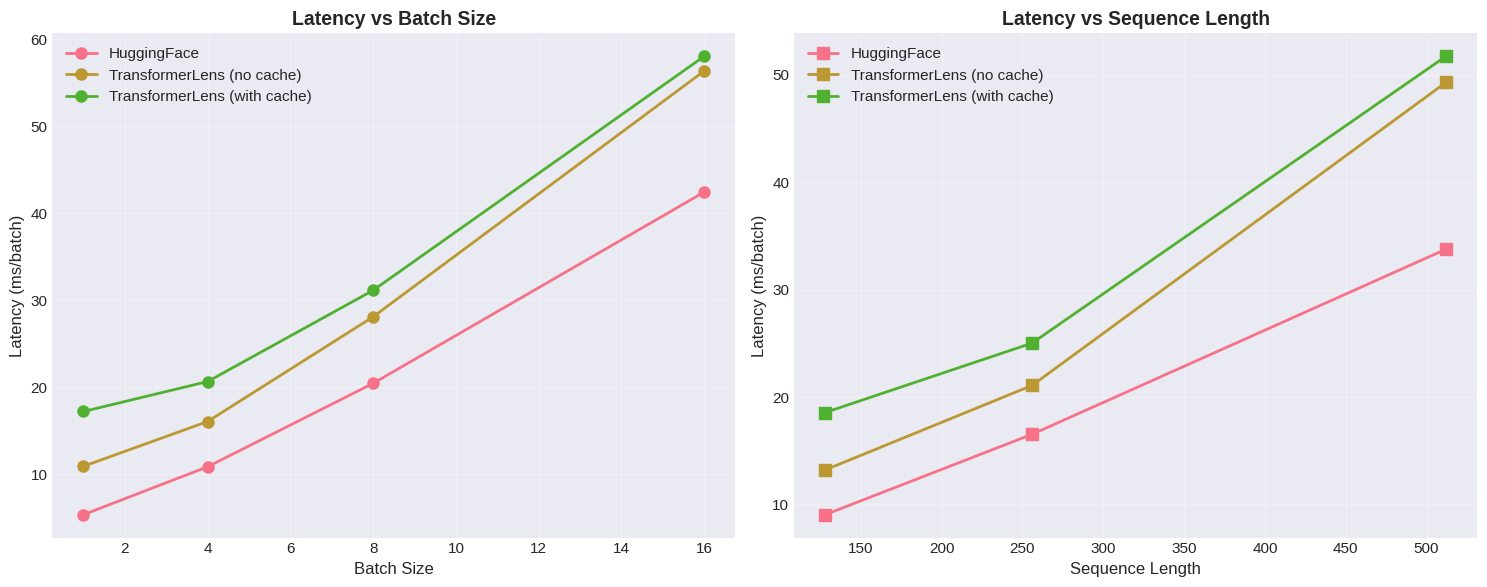

In [50]:
# Latency by batch size and sequence length
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Latency by batch size
ax1 = axes[0]
for impl in df['implementation'].unique():
    impl_df = df[df['implementation'] == impl]
    grouped = impl_df.groupby('batch_size')['latency_ms_per_batch'].mean()
    ax1.plot(grouped.index, grouped.values, marker='o', label=impl, linewidth=2, markersize=8)

ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Latency (ms/batch)', fontsize=12)
ax1.set_title('Latency vs Batch Size', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Latency by sequence length
ax2 = axes[1]
for impl in df['implementation'].unique():
    impl_df = df[df['implementation'] == impl]
    grouped = impl_df.groupby('sequence_length')['latency_ms_per_batch'].mean()
    ax2.plot(grouped.index, grouped.values, marker='s', label=impl, linewidth=2, markersize=8)

ax2.set_xlabel('Sequence Length', fontsize=12)
ax2.set_ylabel('Latency (ms/batch)', fontsize=12)
ax2.set_title('Latency vs Sequence Length', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Throughput Comparison

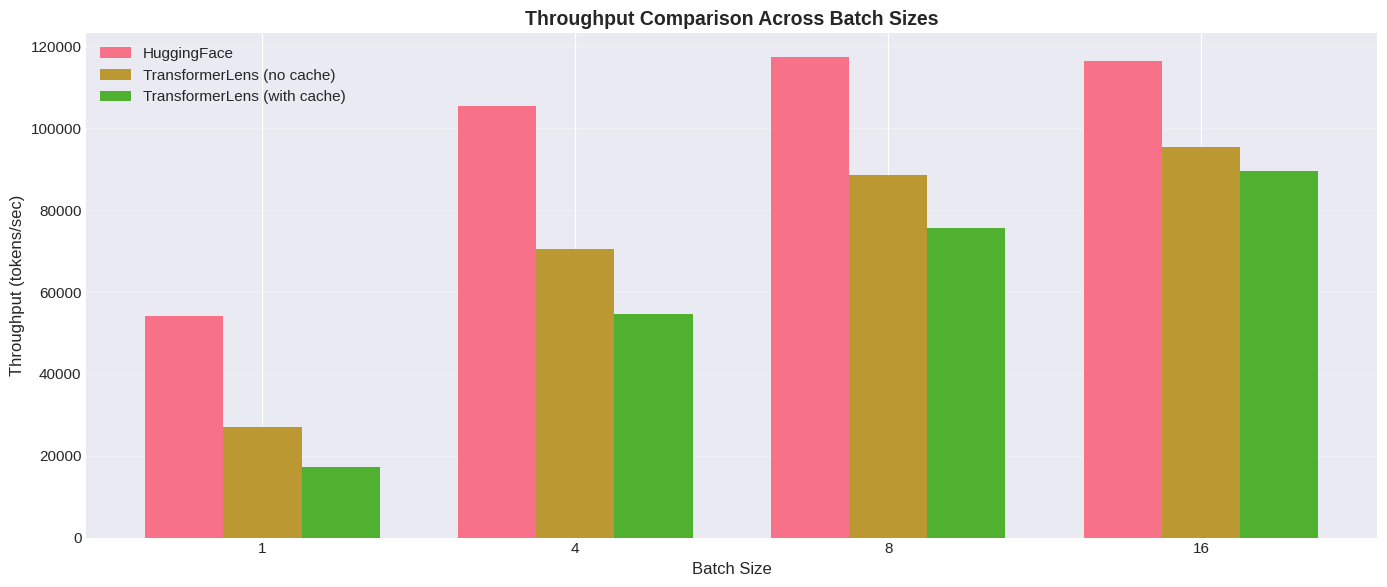

In [51]:
# Create grouped bar chart for throughput
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for grouped bar chart
batch_sizes = sorted(df['batch_size'].unique())
implementations = df['implementation'].unique()
x = np.arange(len(batch_sizes))
width = 0.25

for i, impl in enumerate(implementations):
    impl_df = df[df['implementation'] == impl]
    throughputs = []
    for bs in batch_sizes:
        bs_df = impl_df[impl_df['batch_size'] == bs]
        throughputs.append(bs_df['throughput_tokens_per_sec'].mean())
    
    ax.bar(x + i*width, throughputs, width, label=impl)

ax.set_xlabel('Batch Size', fontsize=12)
ax.set_ylabel('Throughput (tokens/sec)', fontsize=12)
ax.set_title('Throughput Comparison Across Batch Sizes', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(batch_sizes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Performance Overhead Analysis

In [52]:
# Calculate overhead compared to HuggingFace
hf_df = df[df['implementation'] == 'HuggingFace']
tl_no_cache_df = df[df['implementation'] == 'TransformerLens (no cache)']
tl_cache_df = df[df['implementation'] == 'TransformerLens (with cache)']

# Function to calculate overhead
def calculate_overhead(base_df, compare_df, metric):
    overhead_data = []
    for bs in sorted(df['batch_size'].unique()):
        for sl in sorted(df['sequence_length'].unique()):
            base_val = base_df[(base_df['batch_size'] == bs) & 
                              (base_df['sequence_length'] == sl)][metric].values
            compare_val = compare_df[(compare_df['batch_size'] == bs) & 
                                    (compare_df['sequence_length'] == sl)][metric].values
            
            if len(base_val) > 0 and len(compare_val) > 0:
                if metric == 'throughput_tokens_per_sec':
                    overhead = ((base_val[0] - compare_val[0]) / base_val[0]) * 100
                else:  # latency or memory
                    overhead = ((compare_val[0] - base_val[0]) / base_val[0]) * 100
                
                overhead_data.append({
                    'batch_size': bs,
                    'sequence_length': sl,
                    'overhead_percent': overhead
                })
    
    return pd.DataFrame(overhead_data)

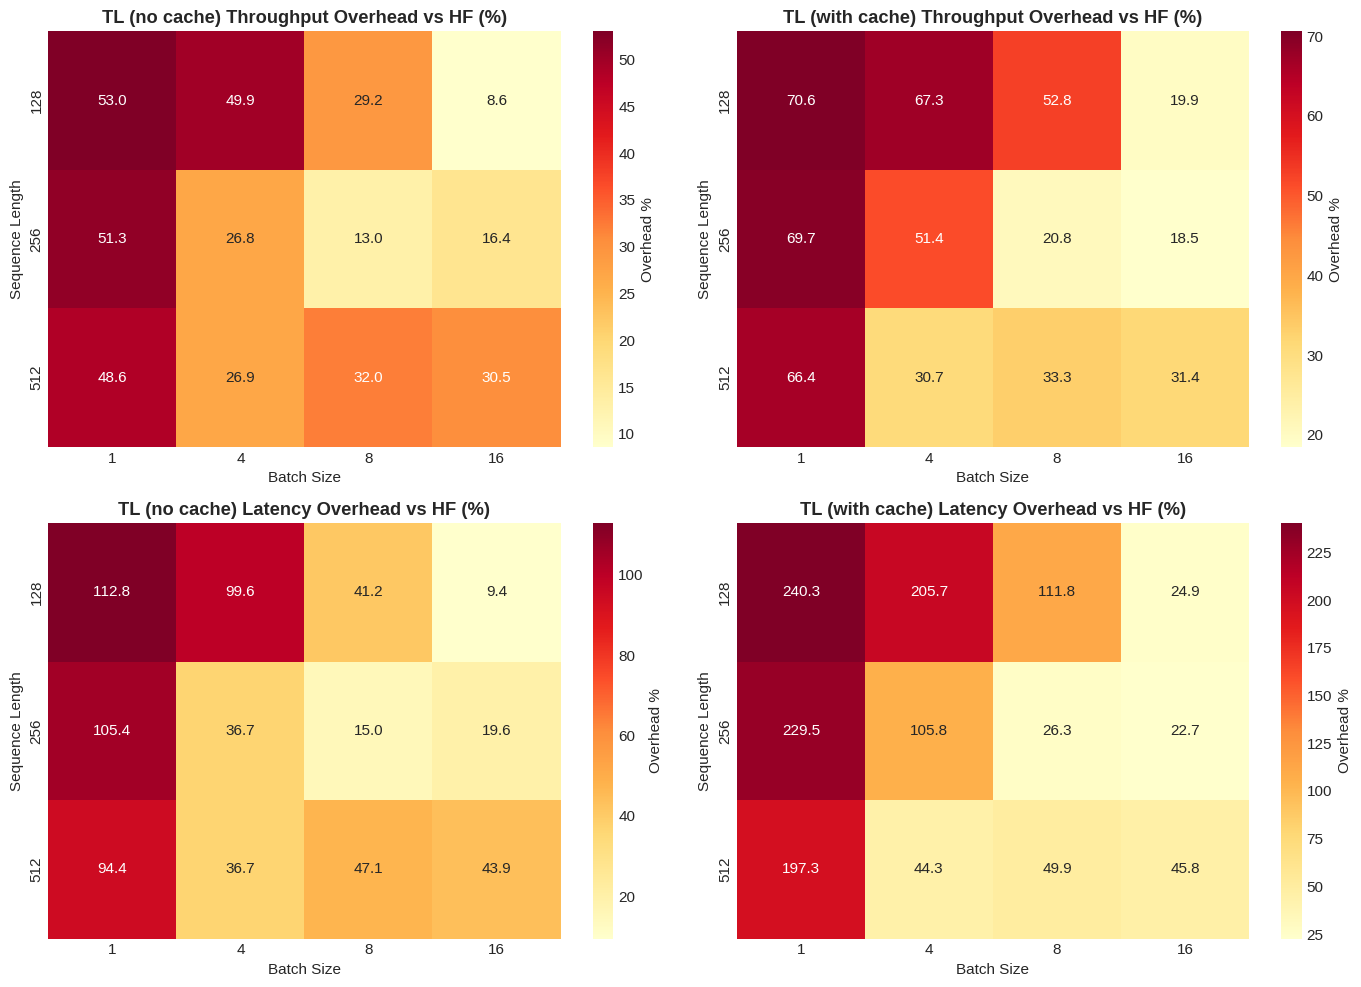

In [53]:
# Calculate overheads
tl_throughput_overhead = calculate_overhead(hf_df, tl_no_cache_df, 'throughput_tokens_per_sec')
tl_cache_throughput_overhead = calculate_overhead(hf_df, tl_cache_df, 'throughput_tokens_per_sec')
tl_latency_overhead = calculate_overhead(hf_df, tl_no_cache_df, 'latency_ms_per_batch')
tl_cache_latency_overhead = calculate_overhead(hf_df, tl_cache_df, 'latency_ms_per_batch')

# Plot overhead heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Throughput overhead - TL no cache
if not tl_throughput_overhead.empty:
    pivot1 = tl_throughput_overhead.pivot(index='sequence_length', 
                                          columns='batch_size', 
                                          values='overhead_percent')
    sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0,0], cbar_kws={'label': 'Overhead %'})
    axes[0,0].set_title('TL (no cache) Throughput Overhead vs HF (%)', fontweight='bold')
    axes[0,0].set_xlabel('Batch Size')
    axes[0,0].set_ylabel('Sequence Length')

# Throughput overhead - TL with cache
if not tl_cache_throughput_overhead.empty:
    pivot2 = tl_cache_throughput_overhead.pivot(index='sequence_length', 
                                                columns='batch_size', 
                                                values='overhead_percent')
    sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0,1], cbar_kws={'label': 'Overhead %'})
    axes[0,1].set_title('TL (with cache) Throughput Overhead vs HF (%)', fontweight='bold')
    axes[0,1].set_xlabel('Batch Size')
    axes[0,1].set_ylabel('Sequence Length')

# Latency overhead - TL no cache
if not tl_latency_overhead.empty:
    pivot3 = tl_latency_overhead.pivot(index='sequence_length', 
                                       columns='batch_size', 
                                       values='overhead_percent')
    sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[1,0], cbar_kws={'label': 'Overhead %'})
    axes[1,0].set_title('TL (no cache) Latency Overhead vs HF (%)', fontweight='bold')
    axes[1,0].set_xlabel('Batch Size')
    axes[1,0].set_ylabel('Sequence Length')

# Latency overhead - TL with cache
if not tl_cache_latency_overhead.empty:
    pivot4 = tl_cache_latency_overhead.pivot(index='sequence_length', 
                                             columns='batch_size', 
                                             values='overhead_percent')
    sns.heatmap(pivot4, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[1,1], cbar_kws={'label': 'Overhead %'})
    axes[1,1].set_title('TL (with cache) Latency Overhead vs HF (%)', fontweight='bold')
    axes[1,1].set_xlabel('Batch Size')
    axes[1,1].set_ylabel('Sequence Length')

plt.tight_layout()
plt.show()

### 5.1 Memory Overhead Analysis

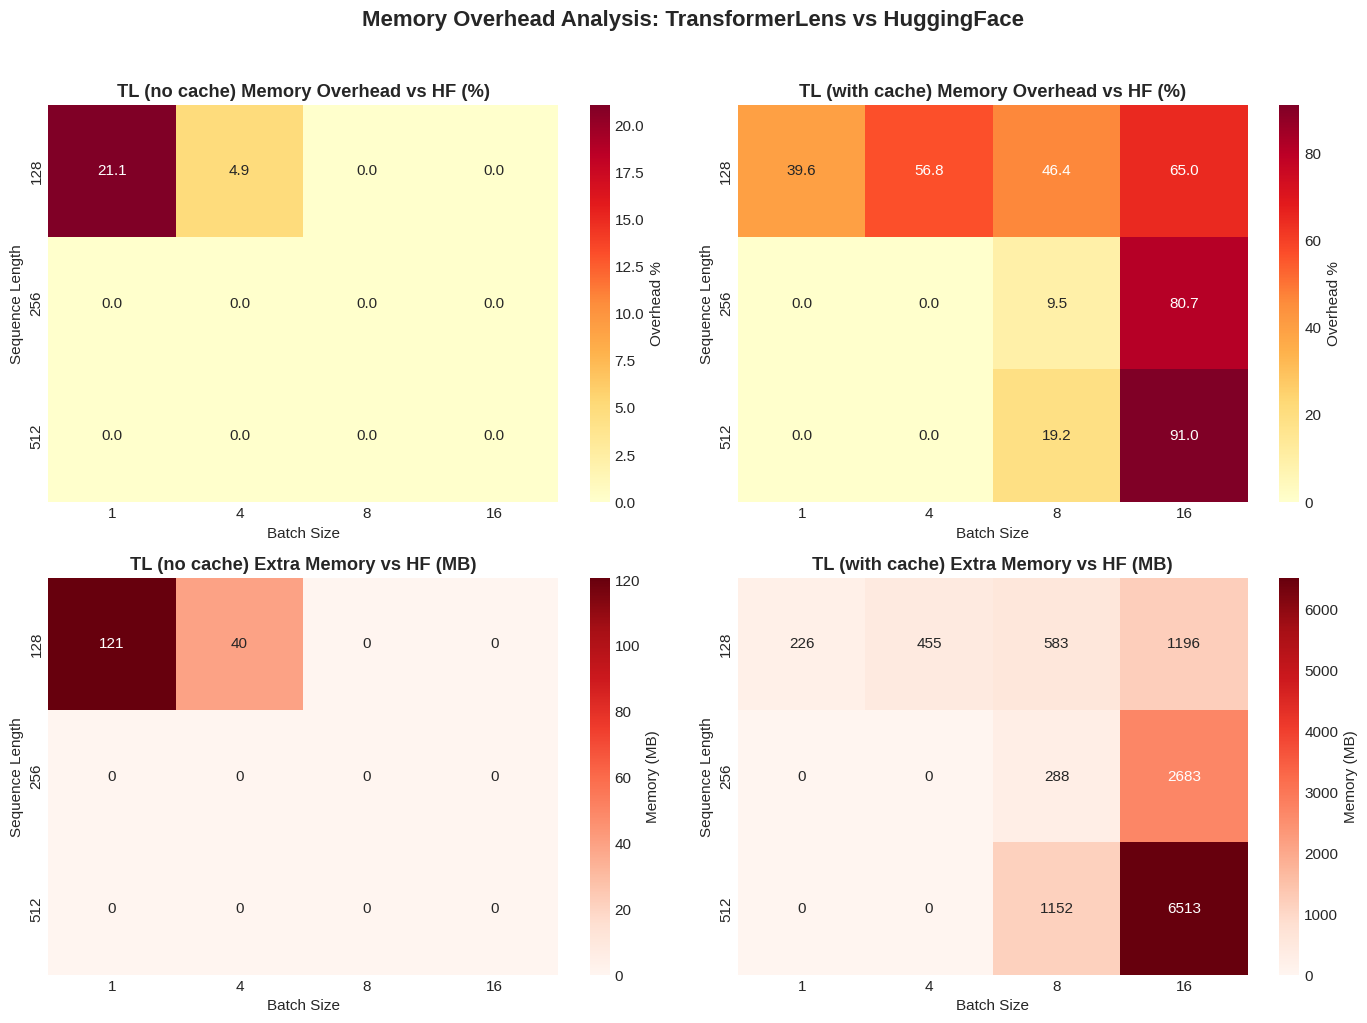


Memory Overhead Summary:
TL (no cache) average memory overhead: 2.2%
TL (no cache) maximum memory overhead: 21.1%
TL (with cache) average memory overhead: 34.0%
TL (with cache) maximum memory overhead: 91.0%

TL (no cache) average extra memory: 13.3 MB
TL (no cache) maximum extra memory: 120.5 MB
TL (with cache) average extra memory: 1091.5 MB
TL (with cache) maximum extra memory: 6513.5 MB


In [54]:
# Calculate memory overhead compared to HuggingFace
tl_memory_overhead = calculate_overhead(hf_df, tl_no_cache_df, 'peak_memory_mb')
tl_cache_memory_overhead = calculate_overhead(hf_df, tl_cache_df, 'peak_memory_mb')

# Also calculate absolute memory difference
def calculate_memory_diff(base_df, compare_df):
    memory_diff_data = []
    for bs in sorted(df['batch_size'].unique()):
        for sl in sorted(df['sequence_length'].unique()):
            base_val = base_df[(base_df['batch_size'] == bs) & 
                              (base_df['sequence_length'] == sl)]['peak_memory_mb'].values
            compare_val = compare_df[(compare_df['batch_size'] == bs) & 
                                    (compare_df['sequence_length'] == sl)]['peak_memory_mb'].values
            
            if len(base_val) > 0 and len(compare_val) > 0:
                diff_mb = compare_val[0] - base_val[0]
                memory_diff_data.append({
                    'batch_size': bs,
                    'sequence_length': sl,
                    'memory_diff_mb': diff_mb
                })
    
    return pd.DataFrame(memory_diff_data)

tl_memory_diff = calculate_memory_diff(hf_df, tl_no_cache_df)
tl_cache_memory_diff = calculate_memory_diff(hf_df, tl_cache_df)

# Plot memory overhead heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Memory overhead % - TL no cache
if not tl_memory_overhead.empty:
    pivot1 = tl_memory_overhead.pivot(index='sequence_length', 
                                      columns='batch_size', 
                                      values='overhead_percent')
    sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0,0], cbar_kws={'label': 'Overhead %'})
    axes[0,0].set_title('TL (no cache) Memory Overhead vs HF (%)', fontweight='bold')
    axes[0,0].set_xlabel('Batch Size')
    axes[0,0].set_ylabel('Sequence Length')

# Memory overhead % - TL with cache
if not tl_cache_memory_overhead.empty:
    pivot2 = tl_cache_memory_overhead.pivot(index='sequence_length', 
                                            columns='batch_size', 
                                            values='overhead_percent')
    sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0,1], cbar_kws={'label': 'Overhead %'})
    axes[0,1].set_title('TL (with cache) Memory Overhead vs HF (%)', fontweight='bold')
    axes[0,1].set_xlabel('Batch Size')
    axes[0,1].set_ylabel('Sequence Length')

# Absolute memory difference - TL no cache
if not tl_memory_diff.empty:
    pivot3 = tl_memory_diff.pivot(index='sequence_length', 
                                  columns='batch_size', 
                                  values='memory_diff_mb')
    sns.heatmap(pivot3, annot=True, fmt='.0f', cmap='Reds', 
                ax=axes[1,0], cbar_kws={'label': 'Memory (MB)'})
    axes[1,0].set_title('TL (no cache) Extra Memory vs HF (MB)', fontweight='bold')
    axes[1,0].set_xlabel('Batch Size')
    axes[1,0].set_ylabel('Sequence Length')

# Absolute memory difference - TL with cache
if not tl_cache_memory_diff.empty:
    pivot4 = tl_cache_memory_diff.pivot(index='sequence_length', 
                                        columns='batch_size', 
                                        values='memory_diff_mb')
    sns.heatmap(pivot4, annot=True, fmt='.0f', cmap='Reds', 
                ax=axes[1,1], cbar_kws={'label': 'Memory (MB)'})
    axes[1,1].set_title('TL (with cache) Extra Memory vs HF (MB)', fontweight='bold')
    axes[1,1].set_xlabel('Batch Size')
    axes[1,1].set_ylabel('Sequence Length')

plt.suptitle('Memory Overhead Analysis: TransformerLens vs HuggingFace', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nMemory Overhead Summary:")
print("="*60)
if not tl_memory_overhead.empty:
    avg_overhead = tl_memory_overhead['overhead_percent'].mean()
    max_overhead = tl_memory_overhead['overhead_percent'].max()
    print(f"TL (no cache) average memory overhead: {avg_overhead:.1f}%")
    print(f"TL (no cache) maximum memory overhead: {max_overhead:.1f}%")

if not tl_cache_memory_overhead.empty:
    avg_overhead = tl_cache_memory_overhead['overhead_percent'].mean()
    max_overhead = tl_cache_memory_overhead['overhead_percent'].max()
    print(f"TL (with cache) average memory overhead: {avg_overhead:.1f}%")
    print(f"TL (with cache) maximum memory overhead: {max_overhead:.1f}%")

if not tl_memory_diff.empty:
    avg_diff = tl_memory_diff['memory_diff_mb'].mean()
    max_diff = tl_memory_diff['memory_diff_mb'].max()
    print(f"\nTL (no cache) average extra memory: {avg_diff:.1f} MB")
    print(f"TL (no cache) maximum extra memory: {max_diff:.1f} MB")

if not tl_cache_memory_diff.empty:
    avg_diff = tl_cache_memory_diff['memory_diff_mb'].mean()
    max_diff = tl_cache_memory_diff['memory_diff_mb'].max()
    print(f"TL (with cache) average extra memory: {avg_diff:.1f} MB")
    print(f"TL (with cache) maximum extra memory: {max_diff:.1f} MB")

### 5.2 Comprehensive Overhead Bar Charts

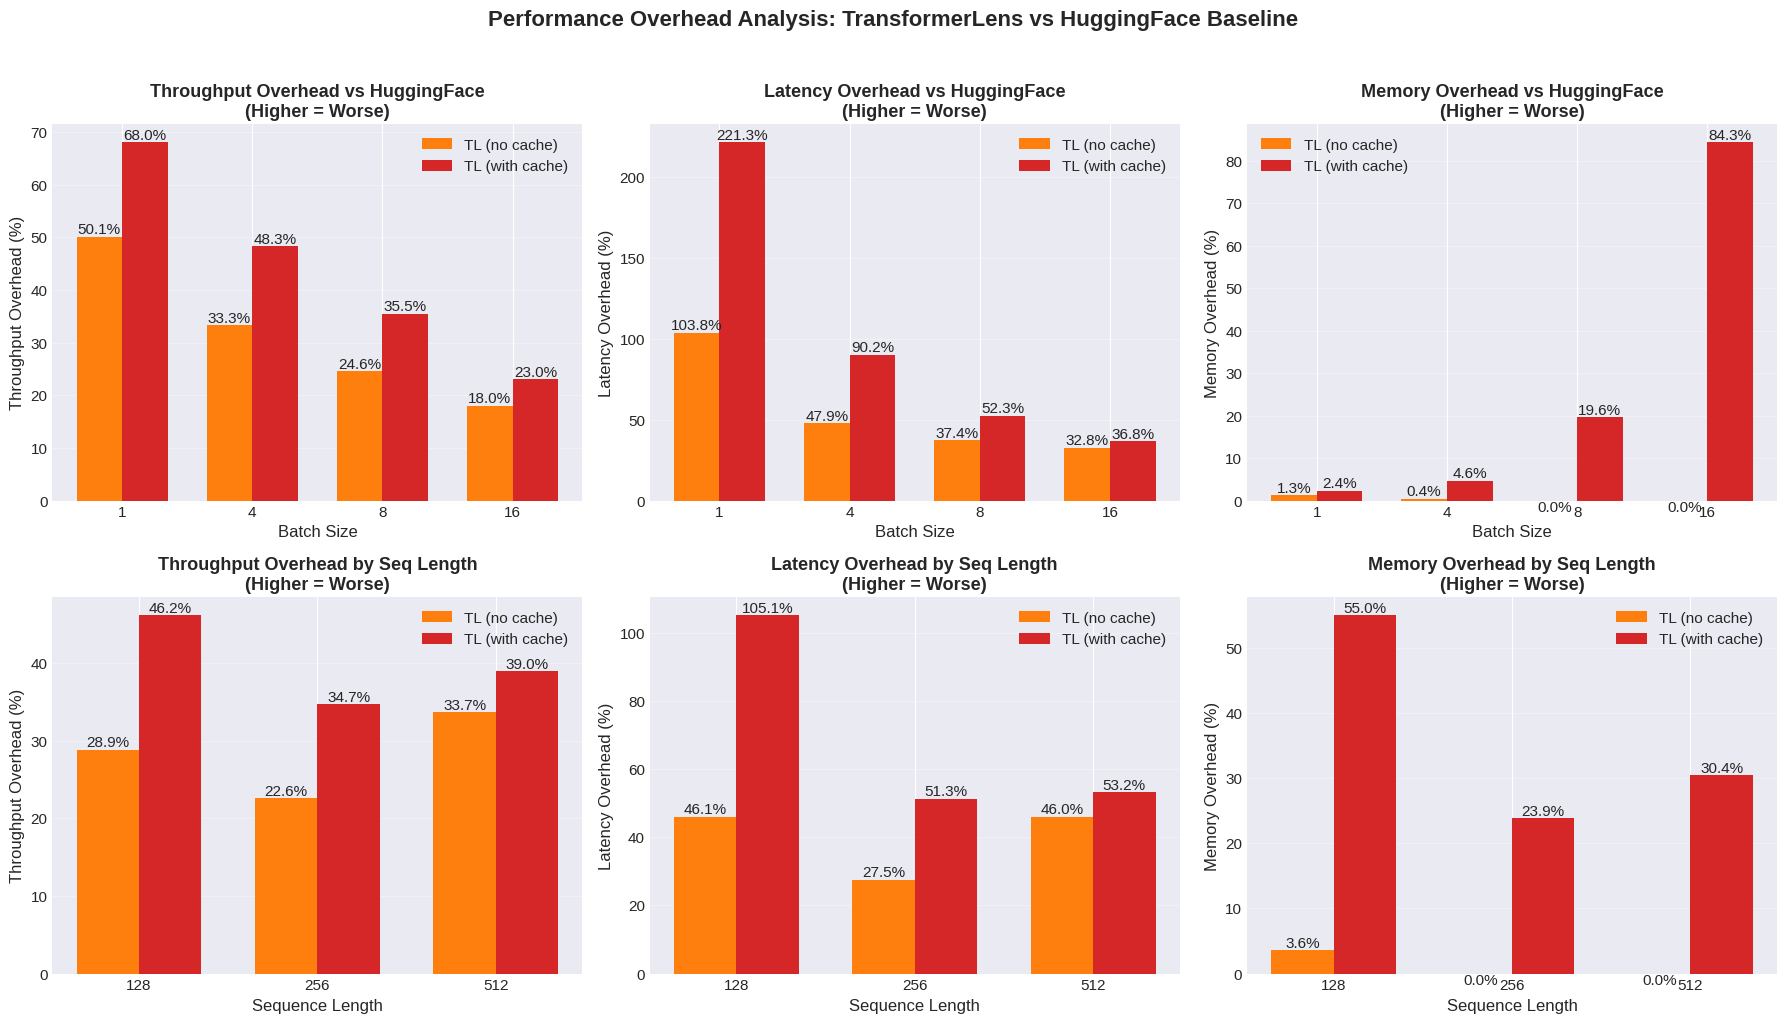


Overhead Summary (Average across all configurations):
Metric               TL (no cache)             TL (with cache)          
----------------------------------------------------------------------
Throughput           31.5% slower           43.7% slower
Latency              55.5% higher           100.1% higher
Memory               0.4% more           27.7% more


In [55]:
# Create comprehensive overhead comparison bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Prepare data for grouped bar charts
batch_sizes = sorted(df['batch_size'].unique())
x = np.arange(len(batch_sizes))
width = 0.35

# Calculate average overheads for each batch size
def calculate_avg_overhead_by_batch(hf_df, compare_df, metric, is_throughput=False):
    overheads = []
    for bs in batch_sizes:
        hf_vals = hf_df[hf_df['batch_size'] == bs][metric].values
        compare_vals = compare_df[compare_df['batch_size'] == bs][metric].values
        
        if len(hf_vals) > 0 and len(compare_vals) > 0:
            hf_avg = hf_vals.mean()
            compare_avg = compare_vals.mean()
            if is_throughput:
                # For throughput, lower is worse, so invert the calculation
                overhead = ((hf_avg - compare_avg) / hf_avg) * 100
            else:
                # For latency and memory, higher is worse
                overhead = ((compare_avg - hf_avg) / hf_avg) * 100
            overheads.append(overhead)
        else:
            overheads.append(0)
    return overheads

# 1. Throughput Overhead
ax1 = axes[0, 0]
tl_throughput_overhead = calculate_avg_overhead_by_batch(hf_df, tl_no_cache_df, 'throughput_tokens_per_sec', True)
tl_cache_throughput_overhead = calculate_avg_overhead_by_batch(hf_df, tl_cache_df, 'throughput_tokens_per_sec', True)

bars1 = ax1.bar(x - width/2, tl_throughput_overhead, width, label='TL (no cache)', color='#ff7f0e')
bars2 = ax1.bar(x + width/2, tl_cache_throughput_overhead, width, label='TL (with cache)', color='#d62728')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Throughput Overhead (%)', fontsize=12)
ax1.set_title('Throughput Overhead vs HuggingFace\n(Higher = Worse)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(batch_sizes)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 2. Latency Overhead
ax2 = axes[0, 1]
tl_latency_overhead = calculate_avg_overhead_by_batch(hf_df, tl_no_cache_df, 'latency_ms_per_batch')
tl_cache_latency_overhead = calculate_avg_overhead_by_batch(hf_df, tl_cache_df, 'latency_ms_per_batch')

bars3 = ax2.bar(x - width/2, tl_latency_overhead, width, label='TL (no cache)', color='#ff7f0e')
bars4 = ax2.bar(x + width/2, tl_cache_latency_overhead, width, label='TL (with cache)', color='#d62728')

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

ax2.set_xlabel('Batch Size', fontsize=12)
ax2.set_ylabel('Latency Overhead (%)', fontsize=12)
ax2.set_title('Latency Overhead vs HuggingFace\n(Higher = Worse)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(batch_sizes)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 3. Memory Overhead
ax3 = axes[0, 2]
tl_memory_overhead_pct = calculate_avg_overhead_by_batch(hf_df, tl_no_cache_df, 'peak_memory_mb')
tl_cache_memory_overhead_pct = calculate_avg_overhead_by_batch(hf_df, tl_cache_df, 'peak_memory_mb')

bars5 = ax3.bar(x - width/2, tl_memory_overhead_pct, width, label='TL (no cache)', color='#ff7f0e')
bars6 = ax3.bar(x + width/2, tl_cache_memory_overhead_pct, width, label='TL (with cache)', color='#d62728')

for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

ax3.set_xlabel('Batch Size', fontsize=12)
ax3.set_ylabel('Memory Overhead (%)', fontsize=12)
ax3.set_title('Memory Overhead vs HuggingFace\n(Higher = Worse)', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(batch_sizes)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Now do the same for sequence lengths
seq_lengths = sorted(df['sequence_length'].unique())
x_seq = np.arange(len(seq_lengths))

def calculate_avg_overhead_by_seq(hf_df, compare_df, metric, is_throughput=False):
    overheads = []
    for sl in seq_lengths:
        hf_vals = hf_df[hf_df['sequence_length'] == sl][metric].values
        compare_vals = compare_df[compare_df['sequence_length'] == sl][metric].values
        
        if len(hf_vals) > 0 and len(compare_vals) > 0:
            hf_avg = hf_vals.mean()
            compare_avg = compare_vals.mean()
            if is_throughput:
                overhead = ((hf_avg - compare_avg) / hf_avg) * 100
            else:
                overhead = ((compare_avg - hf_avg) / hf_avg) * 100
            overheads.append(overhead)
        else:
            overheads.append(0)
    return overheads

# 4. Throughput Overhead by Sequence Length
ax4 = axes[1, 0]
tl_throughput_overhead_seq = calculate_avg_overhead_by_seq(hf_df, tl_no_cache_df, 'throughput_tokens_per_sec', True)
tl_cache_throughput_overhead_seq = calculate_avg_overhead_by_seq(hf_df, tl_cache_df, 'throughput_tokens_per_sec', True)

bars7 = ax4.bar(x_seq - width/2, tl_throughput_overhead_seq, width, label='TL (no cache)', color='#ff7f0e')
bars8 = ax4.bar(x_seq + width/2, tl_cache_throughput_overhead_seq, width, label='TL (with cache)', color='#d62728')

for bars in [bars7, bars8]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

ax4.set_xlabel('Sequence Length', fontsize=12)
ax4.set_ylabel('Throughput Overhead (%)', fontsize=12)
ax4.set_title('Throughput Overhead by Seq Length\n(Higher = Worse)', fontsize=13, fontweight='bold')
ax4.set_xticks(x_seq)
ax4.set_xticklabels(seq_lengths)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 5. Latency Overhead by Sequence Length
ax5 = axes[1, 1]
tl_latency_overhead_seq = calculate_avg_overhead_by_seq(hf_df, tl_no_cache_df, 'latency_ms_per_batch')
tl_cache_latency_overhead_seq = calculate_avg_overhead_by_seq(hf_df, tl_cache_df, 'latency_ms_per_batch')

bars9 = ax5.bar(x_seq - width/2, tl_latency_overhead_seq, width, label='TL (no cache)', color='#ff7f0e')
bars10 = ax5.bar(x_seq + width/2, tl_cache_latency_overhead_seq, width, label='TL (with cache)', color='#d62728')

for bars in [bars9, bars10]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

ax5.set_xlabel('Sequence Length', fontsize=12)
ax5.set_ylabel('Latency Overhead (%)', fontsize=12)
ax5.set_title('Latency Overhead by Seq Length\n(Higher = Worse)', fontsize=13, fontweight='bold')
ax5.set_xticks(x_seq)
ax5.set_xticklabels(seq_lengths)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 6. Memory Overhead by Sequence Length
ax6 = axes[1, 2]
tl_memory_overhead_seq = calculate_avg_overhead_by_seq(hf_df, tl_no_cache_df, 'peak_memory_mb')
tl_cache_memory_overhead_seq = calculate_avg_overhead_by_seq(hf_df, tl_cache_df, 'peak_memory_mb')

bars11 = ax6.bar(x_seq - width/2, tl_memory_overhead_seq, width, label='TL (no cache)', color='#ff7f0e')
bars12 = ax6.bar(x_seq + width/2, tl_cache_memory_overhead_seq, width, label='TL (with cache)', color='#d62728')

for bars in [bars11, bars12]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

ax6.set_xlabel('Sequence Length', fontsize=12)
ax6.set_ylabel('Memory Overhead (%)', fontsize=12)
ax6.set_title('Memory Overhead by Seq Length\n(Higher = Worse)', fontsize=13, fontweight='bold')
ax6.set_xticks(x_seq)
ax6.set_xticklabels(seq_lengths)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.suptitle('Performance Overhead Analysis: TransformerLens vs HuggingFace Baseline', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("\nOverhead Summary (Average across all configurations):")
print("="*70)
print(f"{'Metric':<20} {'TL (no cache)':<25} {'TL (with cache)':<25}")
print("-"*70)
print(f"{'Throughput':<20} {np.mean(tl_throughput_overhead):.1f}% slower{'':<10} {np.mean(tl_cache_throughput_overhead):.1f}% slower")
print(f"{'Latency':<20} {np.mean(tl_latency_overhead):.1f}% higher{'':<10} {np.mean(tl_cache_latency_overhead):.1f}% higher")
print(f"{'Memory':<20} {np.mean(tl_memory_overhead_pct):.1f}% more{'':<10} {np.mean(tl_cache_memory_overhead_pct):.1f}% more")
print("="*70)

## 6. Cache Overhead Analysis

In [56]:
# Compare cache vs no-cache overhead
cache_overhead_data = []

for bs in sorted(df['batch_size'].unique()):
    for sl in sorted(df['sequence_length'].unique()):
        no_cache = tl_no_cache_df[(tl_no_cache_df['batch_size'] == bs) & 
                                  (tl_no_cache_df['sequence_length'] == sl)]
        with_cache = tl_cache_df[(tl_cache_df['batch_size'] == bs) & 
                                (tl_cache_df['sequence_length'] == sl)]
        
        if not no_cache.empty and not with_cache.empty:
            throughput_diff = ((no_cache['throughput_tokens_per_sec'].values[0] - 
                               with_cache['throughput_tokens_per_sec'].values[0]) / 
                              no_cache['throughput_tokens_per_sec'].values[0]) * 100
            
            memory_diff = with_cache['peak_memory_mb'].values[0] - no_cache['peak_memory_mb'].values[0]
            
            cache_overhead_data.append({
                'batch_size': bs,
                'sequence_length': sl,
                'throughput_overhead_percent': throughput_diff,
                'memory_overhead_mb': memory_diff
            })

cache_overhead_df = pd.DataFrame(cache_overhead_data)

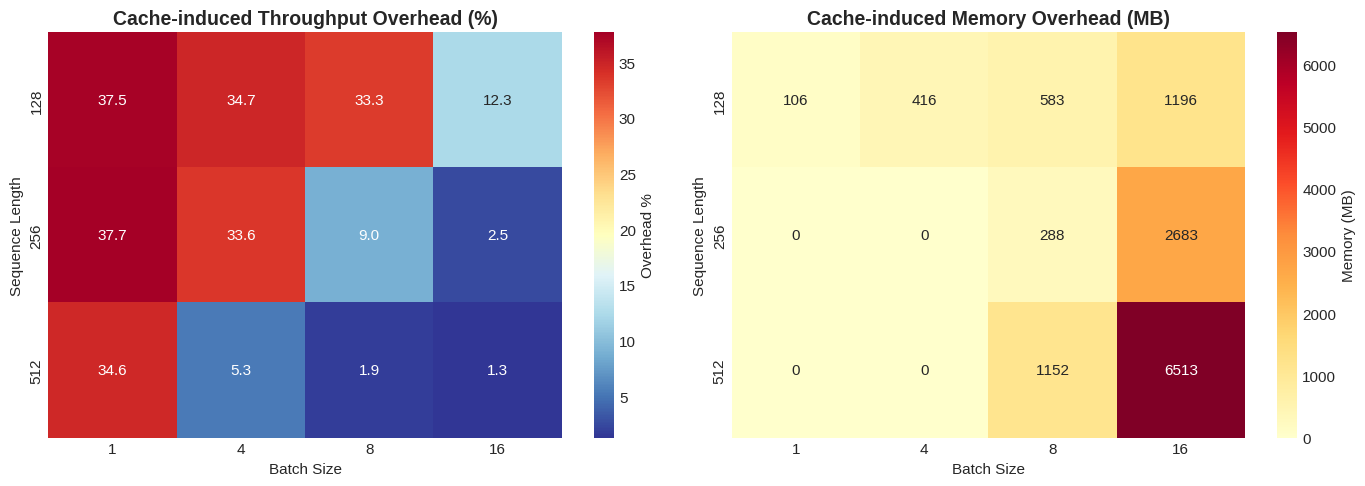

In [57]:
# Visualize cache overhead
if not cache_overhead_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Throughput overhead from cache
    pivot_throughput = cache_overhead_df.pivot(index='sequence_length', 
                                               columns='batch_size', 
                                               values='throughput_overhead_percent')
    sns.heatmap(pivot_throughput, annot=True, fmt='.1f', cmap='RdYlBu_r', 
                ax=axes[0], cbar_kws={'label': 'Overhead %'})
    axes[0].set_title('Cache-induced Throughput Overhead (%)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Batch Size')
    axes[0].set_ylabel('Sequence Length')
    
    # Memory overhead from cache
    pivot_memory = cache_overhead_df.pivot(index='sequence_length', 
                                           columns='batch_size', 
                                           values='memory_overhead_mb')
    sns.heatmap(pivot_memory, annot=True, fmt='.0f', cmap='YlOrRd', 
                ax=axes[1], cbar_kws={'label': 'Memory (MB)'})
    axes[1].set_title('Cache-induced Memory Overhead (MB)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Batch Size')
    axes[1].set_ylabel('Sequence Length')
    
    plt.tight_layout()
    plt.show()

## 7. Summary Statistics

In [58]:
# Create summary table
summary_stats = df.groupby('implementation').agg({
    'throughput_tokens_per_sec': ['mean', 'std', 'min', 'max'],
    'latency_ms_per_batch': ['mean', 'std', 'min', 'max'],
    'peak_memory_mb': ['mean', 'std', 'min', 'max'],
    'load_time_sec': 'mean'
}).round(2)

print("Summary Statistics by Implementation")
print("="*80)
display(summary_stats)

Summary Statistics by Implementation


throughput_tokens_per_sec                      \
                                                  mean       std       min   
implementation                                                               
HuggingFace                                   98379.01  31156.75  25273.97   
TransformerLens (no cache)                    70361.93  31995.89  11875.35   
TransformerLens (with cache)                  59322.76  32595.14   7425.98   

                                        latency_ms_per_batch                \
                                    max                 mean    std    min   
implementation                                                               
HuggingFace                   123822.82                19.78  20.69   5.06   
TransformerLens (no cache)    113138.49                27.87  28.94  10.72   
TransformerLens (with cache)   99167.21                31.77  27.42  17.20   

                                     peak_memory_mb                   \
                                 max           mean      std     min   
implementation                                                         
HuggingFace                    75.95        3507.36  2267.68  572.05   
TransformerLens (no cache)    109.33        3520.69  2249.42  692.57   
TransformerLens (with cache)  110.76        4598.81  3529.29  798.36   

                                       load_time_sec  
                                   max          mean  
implementation                                        
HuggingFace                    7159.54          0.21  
TransformerLens (no cache)     7159.54          0.84  
TransformerLens (with cache)  13673.02          0.82

In [59]:
# Calculate average overheads
if 'HuggingFace' in df['implementation'].values:
    hf_throughput = df[df['implementation'] == 'HuggingFace']['throughput_tokens_per_sec'].mean()
    
    for impl in ['TransformerLens (no cache)', 'TransformerLens (with cache)']:
        if impl in df['implementation'].values:
            impl_throughput = df[df['implementation'] == impl]['throughput_tokens_per_sec'].mean()
            overhead = ((hf_throughput - impl_throughput) / hf_throughput) * 100
            print(f"\n{impl}:")
            print(f"  Average throughput overhead vs HuggingFace: {overhead:.1f}%")
            
            impl_memory = df[df['implementation'] == impl]['peak_memory_mb'].mean()
            hf_memory = df[df['implementation'] == 'HuggingFace']['peak_memory_mb'].mean()
            memory_diff = impl_memory - hf_memory
            print(f"  Average memory overhead vs HuggingFace: {memory_diff:.1f} MB")


TransformerLens (no cache):
  Average throughput overhead vs HuggingFace: 28.5%
  Average memory overhead vs HuggingFace: 13.3 MB

TransformerLens (with cache):
  Average throughput overhead vs HuggingFace: 39.7%
  Average memory overhead vs HuggingFace: 1091.5 MB


## 8. Maximum Capacity Results Visualization

### Load capacity test results

In [60]:
# Load maximum capacity test results
capacity_dir = Path('../results/max_capacity')

capacity_data = None
if capacity_dir.exists():
    capacity_files = list(capacity_dir.glob('capacity_*.json'))
    if capacity_files:
        # Use the most recent file
        latest_capacity = max(capacity_files, key=lambda x: x.stat().st_mtime)
        print(f"Loading capacity results from: {latest_capacity}")
        
        with open(latest_capacity, 'r') as f:
            capacity_data = json.load(f)
            
        print(f"Model: {capacity_data['metadata']['model']}")
        print(f"GPU: {capacity_data['metadata']['gpu_name']}")
        print(f"Total GPU Memory: {capacity_data['metadata']['total_gpu_memory_mb']:.0f} MB")
    else:
        print("No capacity test results found.")
        print("Run: python benchmark/tests/max_capacity_test.py")
else:
    print(f"Capacity results directory {capacity_dir} does not exist.")

Capacity results directory ../results/max_capacity does not exist.


In [61]:
# Visualize maximum batch sizes
if capacity_data:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Prepare data for max batch sizes
    seq_lengths_tested = [128, 256, 512, 1024]
    implementations = []
    max_batch_data = {sl: [] for sl in seq_lengths_tested}
    
    for result in capacity_data['results']:
        impl_name = result['implementation']
        implementations.append(impl_name)
        
        for test in result['max_batch_tests']:
            seq_len = test['sequence_length']
            max_batch = test['max_batch_size']
            if seq_len in seq_lengths_tested:
                max_batch_data[seq_len].append(max_batch)
    
    # Plot 1: Max batch size comparison
    ax1 = axes[0]
    x = np.arange(len(implementations))
    width = 0.2
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, seq_len in enumerate(seq_lengths_tested):
        if max_batch_data[seq_len]:
            offset = (i - 1.5) * width
            bars = ax1.bar(x + offset, max_batch_data[seq_len], width, 
                          label=f'Seq={seq_len}', color=colors[i])
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    ax1.set_xlabel('Implementation', fontsize=12)
    ax1.set_ylabel('Maximum Batch Size', fontsize=12)
    ax1.set_title('Maximum Batch Size by Sequence Length', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([impl.replace(' (', '\\n(') for impl in implementations], fontsize=10)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Max sequence length comparison
    ax2 = axes[1]
    batch_sizes_tested = [1, 4, 8, 16]
    max_seq_data = {bs: [] for bs in batch_sizes_tested}
    
    for result in capacity_data['results']:
        for test in result['max_seq_tests']:
            batch_size = test['batch_size']
            max_seq = test['max_sequence_length']
            if batch_size in batch_sizes_tested:
                max_seq_data[batch_size].append(max_seq)
    
    for i, batch_size in enumerate(batch_sizes_tested):
        if max_seq_data[batch_size]:
            offset = (i - 1.5) * width
            bars = ax2.bar(x + offset, max_seq_data[batch_size], width, 
                          label=f'Batch={batch_size}', color=colors[i])
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    ax2.set_xlabel('Implementation', fontsize=12)
    ax2.set_ylabel('Maximum Sequence Length', fontsize=12)
    ax2.set_title('Maximum Sequence Length by Batch Size', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([impl.replace(' (', '\\n(') for impl in implementations], fontsize=10)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Maximum Capacity Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [62]:
# Memory efficiency heatmap
if capacity_data:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Collect memory efficiency data
    for plot_idx, test_type in enumerate(['max_batch_tests', 'max_seq_tests']):
        efficiency_data = []
        
        for result in capacity_data['results']:
            impl_name = result['implementation']
            
            for test in result[test_type]:
                if test.get('tokens_per_mb', 0) > 0:
                    if test_type == 'max_batch_tests':
                        config_label = f"Seq={test['sequence_length']}"
                    else:
                        config_label = f"Batch={test['batch_size']}"
                    
                    efficiency_data.append({
                        'implementation': impl_name,
                        'config': config_label,
                        'tokens_per_mb': test['tokens_per_mb'],
                        'memory_mb': test['memory_mb']
                    })
        
        if efficiency_data:
            eff_df = pd.DataFrame(efficiency_data)
            
            # Create pivot table for heatmap
            pivot = eff_df.pivot_table(
                index='config',
                columns='implementation',
                values='tokens_per_mb',
                aggfunc='mean'
            )
            
            # Plot heatmap
            ax = axes[plot_idx]
            sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', 
                       ax=ax, cbar_kws={'label': 'Tokens per MB'})
            
            title = 'Memory Efficiency: Max Batch Tests' if test_type == 'max_batch_tests' else 'Memory Efficiency: Max Sequence Tests'
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel('Implementation', fontsize=12)
            ax.set_ylabel('Configuration', fontsize=12)
    
    plt.suptitle('Memory Efficiency Analysis (Higher is Better)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [63]:
# Summary table for maximum capacities
if capacity_data:
    print("="*80)
    print("MAXIMUM CAPACITY SUMMARY")
    print("="*80)
    
    for result in capacity_data['results']:
        impl = result['implementation']
        print(f"\n{impl}:")
        print("-"*50)
        
        # Max batch sizes
        print("\nMax Batch Sizes:")
        for test in result['max_batch_tests']:
            print(f"  Seq={test['sequence_length']:4d}: Batch={test['max_batch_size']:3d} "
                  f"(Memory: {test['memory_mb']:.1f}MB, Efficiency: {test['tokens_per_mb']:.1f} tok/MB)")
        
        # Max sequence lengths
        print("\nMax Sequence Lengths:")
        for test in result['max_seq_tests']:
            print(f"  Batch={test['batch_size']:2d}: Seq={test['max_sequence_length']:4d} "
                  f"(Memory: {test['memory_mb']:.1f}MB, Efficiency: {test['tokens_per_mb']:.1f} tok/MB)")
        
        # Calculate averages
        all_efficiencies = [t['tokens_per_mb'] for t in result['max_batch_tests'] + result['max_seq_tests'] 
                           if t.get('tokens_per_mb', 0) > 0]
        if all_efficiencies:
            avg_efficiency = sum(all_efficiencies) / len(all_efficiencies)
            print(f"\nAverage Memory Efficiency: {avg_efficiency:.1f} tokens/MB")

In [64]:
# Optional: Save all figures to files
save_figures = False  # Set to True to save figures

if save_figures:
    figures_dir = Path('../results/tl_vs_hf/figures')
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    # Re-create and save each figure
    # (Add code here to recreate and save each figure if needed)
    
    print(f"Figures would be saved to: {figures_dir}")
else:
    print("Figures not saved. Set save_figures=True to save them.")

Figures not saved. Set save_figures=True to save them.
